In [74]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target
# print(data.data.shape)
print("Feature matrix shape:", X.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)


(569, 30)
Feature matrix shape: (569, 30)


In [76]:
scaler = StandardScaler()
Xtrain_scaled = scaler.fit_transform(X_train)
Xtest_scaled = scaler.transform(X_test)

In [77]:
#  PCA
pca = PCA(n_components=2)   # Reduce to 2 principal components
Xtrain_pca = pca.fit_transform(Xtrain_scaled)
Xtest_pca = pca.transform(Xtest_scaled)


In [78]:
ann = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42)
ann.fit(Xtrain_pca, y_train)
# ann.fit(X_train, y_train)
y_pred = ann.predict(Xtest_pca)
# y_pred = ann.predict(X_test)

In [79]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9790209790209791

Confusion Matrix:
 [[53  1]
 [ 2 87]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97        54
           1       0.99      0.98      0.98        89

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



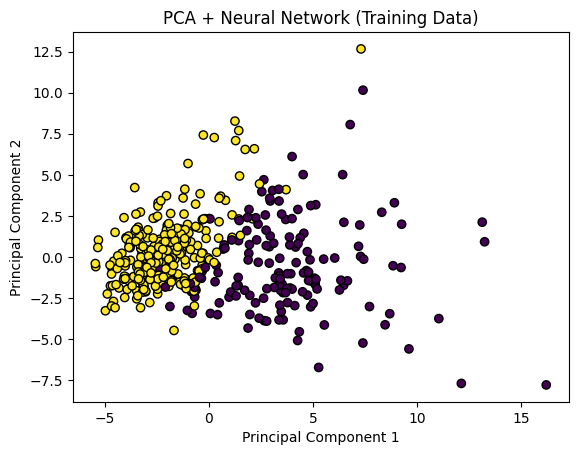

In [80]:
plt.scatter(
    Xtrain_pca[:, 0],
    Xtrain_pca[:, 1],
    c=y_train,
    cmap='viridis',
    edgecolor='k'
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA + Neural Network (Training Data)")
plt.show()